# suggest_v5: under-100k multi-context communication benchmarks

Frozen primary-task evidence report for the eligible section II and III
benchmarks. Task-level completion does not imply that every optional metric,
clustering backend, or robustness extension in `suggest_v5.md` was run. The
notebook distinguishes exact reruns, paper-protocol reconstructions, public
cohort reconstructions, and non-estimable cells.

In [1]:
%%time
from pathlib import Path
import hashlib
import json
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

workspace = Path(os.environ.get("CRYCHIC_BENCHMARK_WORKSPACE", Path.cwd()))
results_root = workspace / "benchmark_work" / "suggest_v5_under100k_20260724"
figure_dir = results_root / "publication_figures"
figure_dir.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.7,
    "lines.linewidth": 1.6,
})
sns.set_style("ticks")

COLORS = {
    "CRYCHIC": "#C43C39",
    "scSeqCommDiff": "#3568A8",
    "CellChat": "#2D8C6F",
    "LIANA": "#D18B2C",
    "STACCato": "#6B4C9A",
    "DCST": "#4A7C59",
    "simple": "#626262",
}

def save_figure(fig, stem):
    for suffix in ("png", "pdf", "svg"):
        fig.savefig(figure_dir / f"{stem}.{suffix}", bbox_inches="tight")

def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

CPU times: user 14 s, sys: 390 ms, total: 14.4 s
Wall time: 1.4 s


## Evidence inventory

In [2]:
%%time
result_dirs = {
    "Tensor-cell2cell": results_root / "tensor_cell2cell",
    "STACCato": results_root / "staccato",
    "DCST": results_root / "dcst",
    "PDAC": results_root / "scaccordion_pdac",
    "AKI": results_root / "scaccordion_aki",
    "RCC fine": results_root / "scaccordion_rcc",
    "RCC coarse": results_root / "scaccordion_rcc_coarse",
    "Signed estimand": results_root / "signed_estimand_contract",
    "Score-engine crossover": (
        results_root / "score_generator_engine_crossover" /
        "formal_20seed_100boot"
    ),
    "Native end-to-end": (
        results_root / "score_generator_engine_crossover" /
        "native_end_to_end_evaluation"
    ),
}

inventory = []
for benchmark, directory in result_dirs.items():
    manifest_path = directory / "manifest.json"
    manifest = json.loads(manifest_path.read_text())
    inventory.append({
        "benchmark": benchmark,
        "status": manifest.get("status"),
        "schema": manifest.get("schema_version"),
        "manifest_sha256": sha256(manifest_path)[:16],
    })
inventory = pd.DataFrame(inventory)
assert inventory["status"].eq("complete").all()
display(inventory)

,benchmark,status,schema,manifest_sha256
0,Tensor-cell2cell,complete,crychic-tensor-cell2cell-under100k-v1,268def9c82365cb2
1,STACCato,complete,crychic-staccato-under100k-v1,dc57813132ef02bf
2,DCST,complete,crychic-dcst-under100k-campaign-v1,cecd8800d2b7758f
3,PDAC,complete,crychic-scaccordion-under100k-v1,a9d12592b32bcb11
4,AKI,complete,crychic-scaccordion-under100k-v1,853ed801e421c278
5,RCC fine,complete,crychic-scaccordion-under100k-v1,2e1c6dfdad6cae54
6,RCC coarse,complete,crychic-scaccordion-under100k-v1,0dd557237cd14383
7,Signed estimand,complete,crychic-signed-estimand-contract-v1,f24dc1544cb71cdd
8,Score-engine crossover,complete,crychic-score-engine-crossover-under100k-v1,58b79da69d022fe2
9,Native end-to-end,complete,crychic-three-group-evaluation-v2,4e98087b5e3343bd


CPU times: user 11.4 ms, sys: 1.01 ms, total: 12.4 ms
Wall time: 12.1 ms


## Known-truth context programs

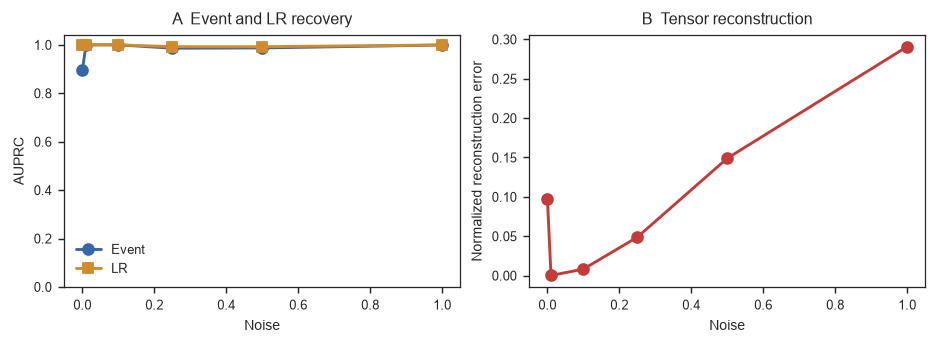

,noise,replicate_count,matched_context_pearson_mean,matched_context_pearson_sd,matched_context_spearman_mean,lr_jaccard_top100_mean,lr_auprc_mean,sender_top1_accuracy_mean,receiver_top1_accuracy_mean,event_auprc_mean,normalized_reconstruction_error_mean,worker_wall_seconds_mean
0,0.00,25,0.6729,0.1308,0.7133,1.0000,1.0000,0.90,0.93,0.8950,0.0969,95.2596
1,0.01,25,0.9986,0.0005,0.9702,1.0000,1.0000,1.00,1.00,1.0000,0.0001,88.5400
2,0.10,25,0.9981,0.0003,0.9702,1.0000,1.0000,1.00,1.00,1.0000,0.0082,95.4625
3,0.25,25,0.9769,0.0927,0.9514,0.9903,0.9924,0.99,0.99,0.9861,0.0488,75.1996
4,0.50,25,0.9727,0.0712,0.9546,0.9899,0.9923,0.99,0.99,0.9872,0.1490,69.2603
5,1.00,25,0.9622,0.0057,0.9591,0.9953,0.9995,1.00,1.00,0.9994,0.2908,65.2508


CPU times: user 879 ms, sys: 75.1 ms, total: 954 ms
Wall time: 979 ms


In [3]:
%%time
tensor = pd.read_csv(
    result_dirs["Tensor-cell2cell"] / "aggregate_metrics.tsv", sep="	"
)
fig, axes = plt.subplots(1, 2, figsize=(7.1, 2.55), constrained_layout=True)
axes[0].plot(
    tensor["noise"], tensor["event_auprc_mean"], marker="o", color="#3568A8"
)
axes[0].plot(
    tensor["noise"], tensor["lr_auprc_mean"], marker="s", color="#D18B2C"
)
axes[0].set(xlabel="Noise", ylabel="AUPRC", title="A  Event and LR recovery")
axes[0].legend(["Event", "LR"], frameon=False)
axes[0].set_ylim(0, 1.04)
axes[1].plot(
    tensor["noise"],
    tensor["normalized_reconstruction_error_mean"],
    marker="o",
    color="#C43C39",
)
axes[1].set(
    xlabel="Noise",
    ylabel="Normalized reconstruction error",
    title="B  Tensor reconstruction",
)
save_figure(fig, "figure_01_tensor_cell2cell")
plt.show()
display(tensor.round(4))

## Condition and batch-confounding simulation

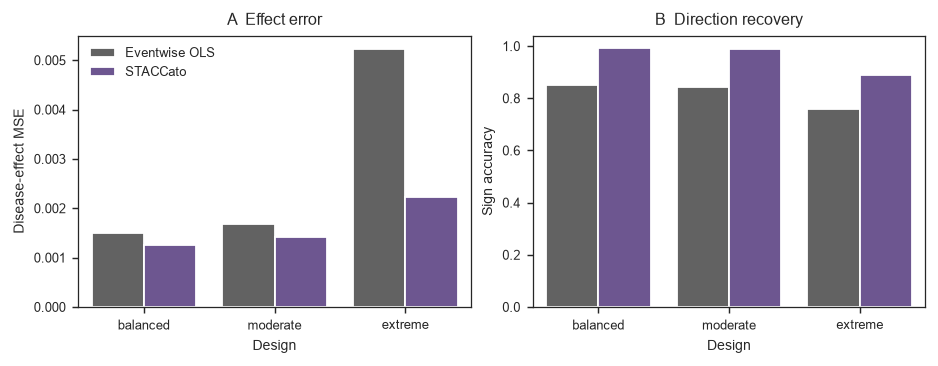

,design,Method,mse_mean,sign_accuracy_mean
0,balanced,Eventwise OLS,0.0015,0.8491
2,balanced,STACCato,0.0013,0.9945
4,extreme,Eventwise OLS,0.0052,0.7597
6,extreme,STACCato,0.0022,0.8901
8,moderate,Eventwise OLS,0.0017,0.8425
10,moderate,STACCato,0.0014,0.9890


CPU times: user 796 ms, sys: 49 ms, total: 846 ms
Wall time: 844 ms


In [4]:
%%time
staccato = pd.read_csv(
    result_dirs["STACCato"] / "aggregate_metrics.tsv", sep="	"
)
keep = staccato[staccato["method"].isin([
    "eventwise_ols_adjusted", "staccato_adjusted"
])].copy()
labels = {
    "eventwise_ols_adjusted": "Eventwise OLS",
    "staccato_adjusted": "STACCato",
}
keep["Method"] = keep["method"].map(labels)
order = ["balanced", "moderate", "extreme"]
fig, axes = plt.subplots(1, 2, figsize=(7.1, 2.7), constrained_layout=True)
sns.barplot(
    data=keep, x="design", y="mse_mean", hue="Method", order=order,
    palette=["#626262", COLORS["STACCato"]], ax=axes[0]
)
axes[0].set(xlabel="Design", ylabel="Disease-effect MSE", title="A  Effect error")
sns.barplot(
    data=keep, x="design", y="sign_accuracy_mean", hue="Method", order=order,
    palette=["#626262", COLORS["STACCato"]], ax=axes[1]
)
axes[1].set(
    xlabel="Design", ylabel="Sign accuracy", title="B  Direction recovery",
    ylim=(0, 1.04)
)
axes[0].legend(frameon=False, title=None)
axes[1].legend_.remove()
save_figure(fig, "figure_02_staccato")
plt.show()
display(keep[["design", "Method", "mse_mean", "sign_accuracy_mean"]].round(4))

## DCST paper-native independent sweeps

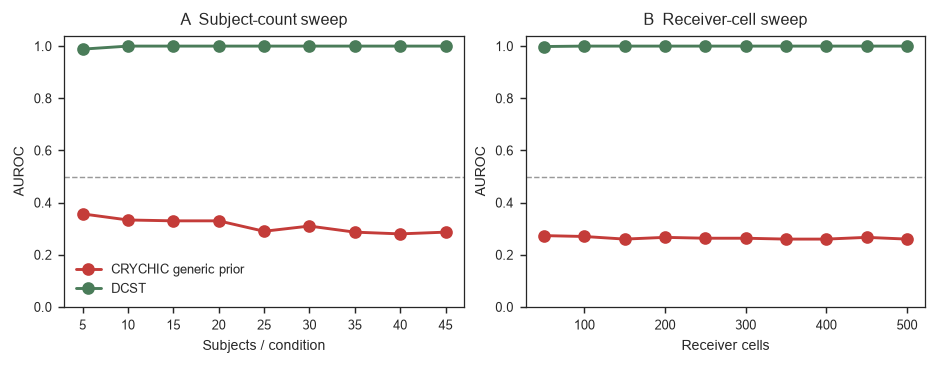

auroc_mean  auprc_mean  \
sweep               Method                                          
receiver_cell_count CRYCHIC generic prior      0.2643      0.2500   
                    DCST                       0.9998      0.9993   
subject_count       CRYCHIC generic prior      0.3115      0.2500   
                    DCST                       0.9987      0.9976   

                                           direction_accuracy_mean  
sweep               Method                                          
receiver_cell_count CRYCHIC generic prior                   0.0000  
                    DCST                                    1.0000  
subject_count       CRYCHIC generic prior                   0.0000  
                    DCST                                    0.9978

CPU times: user 827 ms, sys: 44 ms, total: 871 ms
Wall time: 870 ms


In [5]:
%%time
dcst = pd.read_csv(result_dirs["DCST"] / "aggregate_metrics.tsv", sep="	")
dcst["Method"] = dcst["method"].map({
    "dcst_protocol_reimplementation": "DCST",
    "crychic_generic_synthetic_prior": "CRYCHIC generic prior",
})
palette = {"DCST": COLORS["DCST"], "CRYCHIC generic prior": COLORS["CRYCHIC"]}
fig, axes = plt.subplots(1, 2, figsize=(7.1, 2.7), constrained_layout=True)
for ax, sweep, title, xlabel in (
    (axes[0], "subject_count", "A  Subject-count sweep", "Subjects / condition"),
    (axes[1], "receiver_cell_count", "B  Receiver-cell sweep", "Receiver cells"),
):
    selected = dcst[dcst["sweep"].eq(sweep)]
    for method, group in selected.groupby("Method", sort=False):
        ax.plot(
            group["axis_value"], group["auroc_mean"], marker="o",
            label=method, color=palette[method]
        )
    ax.axhline(0.5, color="#999999", lw=0.8, ls="--")
    ax.set(xlabel=xlabel, ylabel="AUROC", title=title, ylim=(0, 1.04))
axes[0].legend(frameon=False)
save_figure(fig, "figure_03_dcst")
plt.show()
display(
    dcst.groupby(["sweep", "Method"], observed=True)[
        ["auroc_mean", "auprc_mean", "direction_accuracy_mean"]
    ].mean().round(4)
)

## Patient graph phenotype recovery

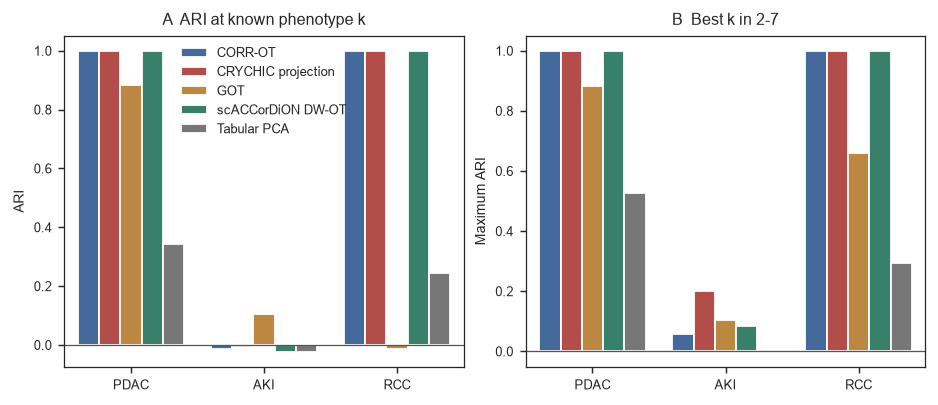

,Cohort,Method,ari_at_true_k,maximum_ari_over_k
0,PDAC,CORR-OT,1.0000,1.0000
1,PDAC,CRYCHIC projection,1.0000,1.0000
2,PDAC,GOT,0.8836,0.8836
3,PDAC,scACCorDiON DW-OT,1.0000,1.0000
4,PDAC,Tabular PCA,0.3433,0.5255
5,AKI,CORR-OT,-0.0142,0.0582
6,AKI,CRYCHIC projection,-0.0084,0.2004
7,AKI,GOT,0.1048,0.1048
8,AKI,scACCorDiON DW-OT,-0.0227,0.0849
9,AKI,Tabular PCA,-0.0227,-0.0010


CPU times: user 1.03 s, sys: 57 ms, total: 1.08 s
Wall time: 1.08 s


In [6]:
%%time
cohorts = []
for cohort, key in (("PDAC", "PDAC"), ("AKI", "AKI"), ("RCC", "RCC fine")):
    table = pd.read_csv(result_dirs[key] / "summary_metrics.tsv", sep="	")
    table["Cohort"] = cohort
    cohorts.append(table)
patient = pd.concat(cohorts, ignore_index=True)
method_labels = {
    "corr_ot": "CORR-OT",
    "crychic_canonical_event_correlation": "CRYCHIC projection",
    "got": "GOT",
    "scaccordion_dw_ot": "scACCorDiON DW-OT",
    "tabular_pca": "Tabular PCA",
}
patient["Method"] = patient["method"].map(method_labels)
patient_palette = ["#3568A8", "#C43C39", "#D18B2C", "#2D8C6F", "#777777"]
fig, axes = plt.subplots(1, 2, figsize=(7.1, 3.0), constrained_layout=True)
sns.barplot(
    data=patient, x="Cohort", y="ari_at_true_k", hue="Method",
    palette=patient_palette, ax=axes[0]
)
axes[0].axhline(0, color="#555555", lw=0.7)
axes[0].set(xlabel="", ylabel="ARI", title="A  ARI at known phenotype k")
sns.barplot(
    data=patient, x="Cohort", y="maximum_ari_over_k", hue="Method",
    palette=patient_palette, ax=axes[1]
)
axes[1].axhline(0, color="#555555", lw=0.7)
axes[1].set(xlabel="", ylabel="Maximum ARI", title="B  Best k in 2-7")
axes[0].legend(frameon=False, title=None, ncol=1, loc="best")
axes[1].legend_.remove()
save_figure(fig, "figure_04_patient_graphs")
plt.show()
display(patient[["Cohort", "Method", "ari_at_true_k", "maximum_ari_over_k"]].round(4))

## RCC annotation-resolution robustness

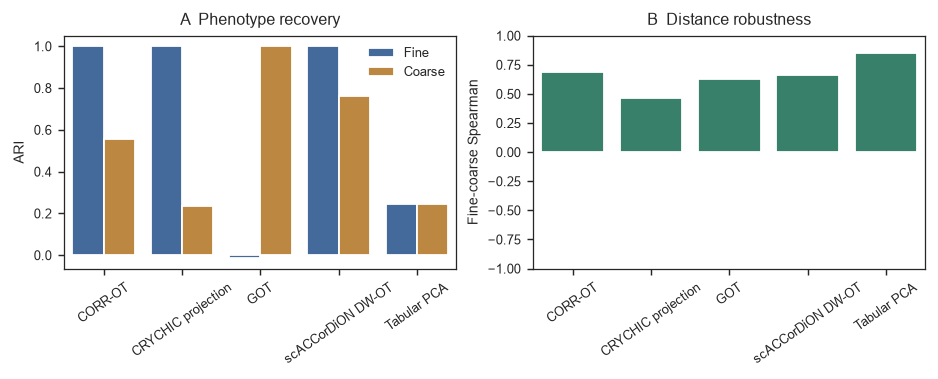

,Method,Spearman
0,CORR-OT,0.6874
1,CRYCHIC projection,0.4659
2,GOT,0.6306
3,scACCorDiON DW-OT,0.6650
4,Tabular PCA,0.8510


CPU times: user 942 ms, sys: 69.1 ms, total: 1.01 s
Wall time: 1.01 s


In [7]:
%%time
rcc_rows = []
for resolution, key in (("Fine", "RCC fine"), ("Coarse", "RCC coarse")):
    table = pd.read_csv(result_dirs[key] / "summary_metrics.tsv", sep="	")
    table["Resolution"] = resolution
    rcc_rows.append(table)
rcc = pd.concat(rcc_rows, ignore_index=True)
rcc["Method"] = rcc["method"].map(method_labels)

distance_correlations = []
for method in sorted(rcc["method"].unique()):
    fine_path = result_dirs["RCC fine"] / "distances" / f"{method}.npz"
    coarse_path = result_dirs["RCC coarse"] / "distances" / f"{method}.npz"
    fine = np.load(fine_path)["distance"]
    coarse = np.load(coarse_path)["distance"]
    upper = np.triu_indices_from(fine, k=1)
    correlation = pd.Series(fine[upper]).corr(
        pd.Series(coarse[upper]), method="spearman"
    )
    distance_correlations.append({
        "Method": method_labels[method], "Spearman": correlation
    })
distance_correlations = pd.DataFrame(distance_correlations)

fig, axes = plt.subplots(1, 2, figsize=(7.1, 2.8), constrained_layout=True)
sns.barplot(
    data=rcc, x="Method", y="ari_at_true_k", hue="Resolution",
    palette=["#3568A8", "#D18B2C"], ax=axes[0]
)
axes[0].set(xlabel="", ylabel="ARI", title="A  Phenotype recovery")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(frameon=False, title=None)
sns.barplot(
    data=distance_correlations, x="Method", y="Spearman", color="#2D8C6F", ax=axes[1]
)
axes[1].set(
    xlabel="", ylabel="Fine-coarse Spearman", title="B  Distance robustness",
    ylim=(-1, 1)
)
axes[1].tick_params(axis="x", rotation=35)
save_figure(fig, "figure_05_rcc_annotation")
plt.show()
display(distance_correlations.round(4))

## Native end-to-end three-group comparison

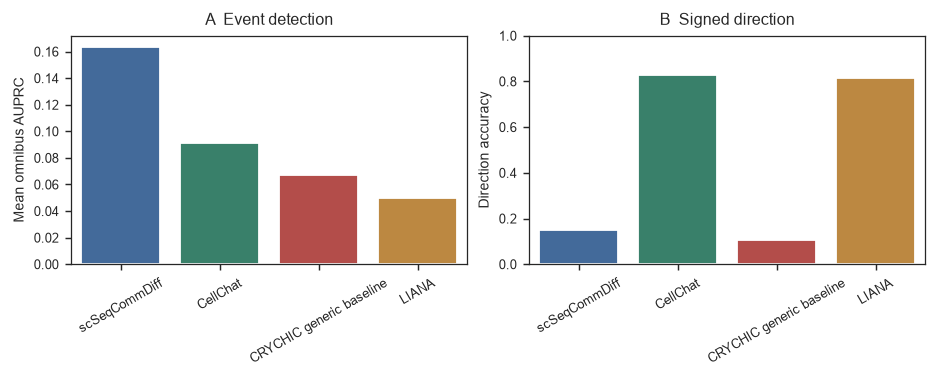

,primary_rank,Method,mean_omnibus_auprc,mean_omnibus_auroc,mean_direction_accuracy_all_active,mean_event_coverage
0,1.0,scSeqCommDiff,0.1638,0.7143,0.1500,1.0
1,2.0,CellChat,0.0909,0.5044,0.8286,1.0
2,3.0,CRYCHIC generic baseline,0.0671,0.3700,0.1071,1.0
3,4.0,LIANA,0.0500,0.0903,0.8143,1.0


CPU times: user 836 ms, sys: 35 ms, total: 871 ms
Wall time: 869 ms


In [8]:
%%time
native = pd.read_csv(
    result_dirs["Native end-to-end"] / "multigroup_method_summary.tsv", sep="	"
)
native["Method"] = native["method_label"]
native_palette = {
    "CRYCHIC generic baseline": COLORS["CRYCHIC"],
    "scSeqCommDiff": COLORS["scSeqCommDiff"],
    "CellChat": COLORS["CellChat"],
    "LIANA": COLORS["LIANA"],
}
native = native.sort_values("primary_rank")
fig, axes = plt.subplots(1, 2, figsize=(7.1, 2.8), constrained_layout=True)
sns.barplot(
    data=native, x="Method", y="mean_omnibus_auprc",
    palette=native_palette, hue="Method", legend=False, ax=axes[0]
)
axes[0].set(xlabel="", ylabel="Mean omnibus AUPRC", title="A  Event detection")
axes[0].tick_params(axis="x", rotation=30)
sns.barplot(
    data=native, x="Method", y="mean_direction_accuracy_all_active",
    palette=native_palette, hue="Method", legend=False, ax=axes[1]
)
axes[1].set(
    xlabel="", ylabel="Direction accuracy", title="B  Signed direction",
    ylim=(0, 1)
)
axes[1].tick_params(axis="x", rotation=30)
save_figure(fig, "figure_06_native_three_group")
plt.show()
display(native[[
    "primary_rank", "Method", "mean_omnibus_auprc", "mean_omnibus_auroc",
    "mean_direction_accuracy_all_active", "mean_event_coverage"
]].round(4))

## Score generator x differential engine crossover

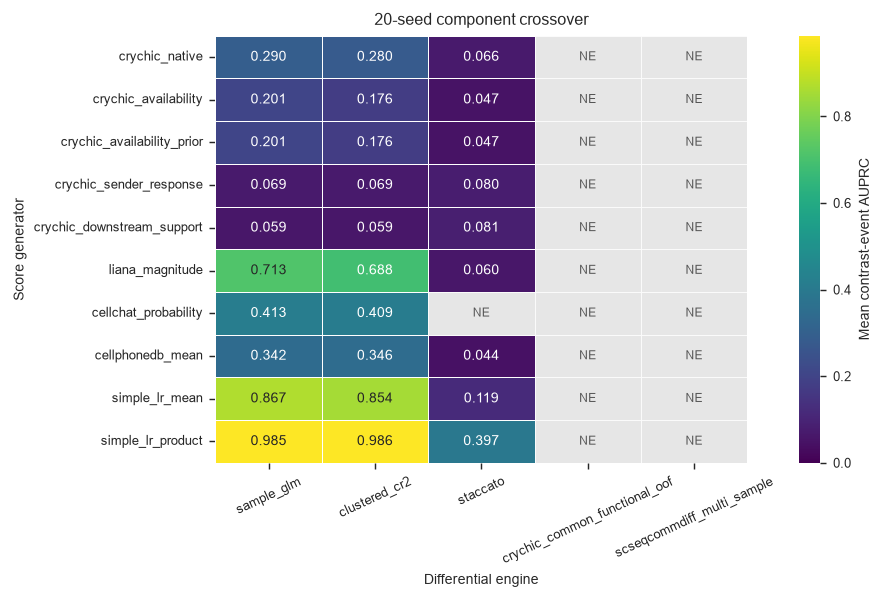

,score_generator,differential_engine,active_datasets,mean_auprc,mean_auroc,mean_calibrated_rmse,mean_direction_accuracy,mean_empirical_fdr,mean_coverage,mean_failure_rate,...,mean_null_false_positive_rate,null_datasets,auprc_ci_lower,auprc_ci_upper,rank_eligible,mean_auprc_rank,mean_auroc_rank,mean_calibrated_rmse_rank,mean_direction_accuracy_rank,primary_rank
0,simple_lr_product,clustered_cr2,20,0.9862,0.9991,0.1789,1.0000,0.5589,1.0,0.0,...,0.0019,20,0.9801,0.9920,True,1.0,1.0,1.0,1.0,1.0
1,simple_lr_product,sample_glm,20,0.9853,0.9990,0.1789,1.0000,0.5746,1.0,0.0,...,0.0019,20,0.9792,0.9908,True,2.0,2.0,1.0,1.0,2.0
2,simple_lr_mean,sample_glm,20,0.8671,0.9865,0.3424,1.0000,0.8295,1.0,0.0,...,0.0022,20,0.8430,0.8896,True,3.0,3.0,4.0,1.0,3.0
3,simple_lr_mean,clustered_cr2,20,0.8540,0.9854,0.3424,1.0000,0.8288,1.0,0.0,...,0.0019,20,0.8291,0.8773,True,4.0,4.0,4.0,1.0,4.0
4,liana_magnitude,sample_glm,20,0.7132,0.9133,0.4035,0.8214,0.4664,1.0,0.0,...,0.0004,20,0.6681,0.7570,True,5.0,5.0,20.0,6.0,5.0
5,liana_magnitude,clustered_cr2,20,0.6883,0.9045,0.4035,0.8214,0.4403,1.0,0.0,...,0.0011,20,0.6441,0.7340,True,6.0,6.0,20.0,6.0,6.0
6,simple_lr_product,staccato,20,0.3966,0.8253,0.2687,0.8929,0.0000,1.0,0.0,...,0.0000,20,0.3678,0.4267,True,7.0,7.0,3.0,5.0,7.0
7,cellphonedb_mean,clustered_cr2,20,0.3462,0.7822,0.4037,0.1429,0.5114,1.0,0.0,...,0.0759,20,0.3415,0.3492,True,8.0,8.0,26.0,26.0,8.0
8,cellphonedb_mean,sample_glm,20,0.3423,0.7821,0.4037,0.1429,0.6100,1.0,0.0,...,0.0378,20,0.3374,0.3469,True,9.0,9.0,26.0,26.0,9.0
9,crychic_native,sample_glm,20,0.2897,0.6286,0.4036,0.4143,0.2000,1.0,0.0,...,0.0048,20,0.2282,0.3502,True,10.0,12.0,22.0,22.0,10.0


status              reason_code                                            
not_estimable       independent_subject_groups_violate_paired_oof_contract     10
                    no_estimable_event_tensor                                   1
                    public_engine_has_no_external_score_injection_interface    10
observed            estimable_public_score_tensor_interface                    27
partially_observed  estimable_public_score_tensor_interface                     2
Name: cells, dtype: int64

CPU times: user 1.34 s, sys: 132 ms, total: 1.48 s
Wall time: 1.47 s


In [9]:
%%time
crossover = pd.read_csv(
    result_dirs["Score-engine crossover"] / "arm_summary.tsv", sep="	"
)
matrix = pd.read_csv(
    result_dirs["Score-engine crossover"] / "eligibility_matrix.tsv", sep="	"
)
generator_order = [
    "crychic_native", "crychic_availability", "crychic_availability_prior",
    "crychic_sender_response", "crychic_downstream_support", "liana_magnitude",
    "cellchat_probability", "cellphonedb_mean", "simple_lr_mean",
    "simple_lr_product",
]
engine_order = [
    "sample_glm", "clustered_cr2", "staccato",
    "crychic_common_functional_oof", "scseqcommdiff_multi_sample",
]
heat = crossover.pivot(
    index="score_generator", columns="differential_engine", values="mean_auprc"
).reindex(index=generator_order, columns=engine_order)
missing = heat.isna()
fig, ax = plt.subplots(figsize=(6.7, 4.5), constrained_layout=True)
sns.heatmap(
    heat, mask=missing, cmap="viridis", vmin=0,
    vmax=max(0.5, np.nanmax(heat.to_numpy())),
    annot=True, fmt=".3f", linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Mean contrast-event AUPRC"}, ax=ax
)
for row, column in zip(*np.where(missing.to_numpy()), strict=True):
    ax.add_patch(Rectangle(
        (column, row), 1, 1, facecolor="#E6E6E6",
        edgecolor="white", linewidth=0.4
    ))
    ax.text(column + 0.5, row + 0.5, "NE", ha="center", va="center",
            color="#555555", fontsize=6.5)
ax.set(
    xlabel="Differential engine", ylabel="Score generator",
    title="20-seed component crossover"
)
ax.tick_params(axis="x", rotation=25)
save_figure(fig, "figure_07_score_engine_crossover")
plt.show()
display(crossover.sort_values("primary_rank").head(15).round(4))
display(matrix.groupby(["status", "reason_code"], dropna=False).size().rename("cells"))

## Contract gate and compact conclusions

In [10]:
%%time
cases = pd.read_csv(
    result_dirs["Signed estimand"] / "case_results.tsv", sep="	"
)
invariants = pd.read_csv(
    result_dirs["Signed estimand"] / "invariance_results.tsv", sep="	"
)
conclusions = pd.DataFrame([
    {
        "Endpoint": "Signed estimand contract",
        "Result": f"{cases.passed.sum()}/{len(cases)} cases; "
                  f"{invariants.passed.sum()}/{len(invariants)} invariants",
        "Interpretation": (
            "Gate A passed; formal p values remain NE without full-pipeline "
            "resampling."
        ),
    },
    {
        "Endpoint": "Native three-group omnibus AUPRC",
        "Result": "CRYCHIC rank 3/4",
        "Interpretation": (
            "No native canonical accuracy advantage on this planted fixture."
        ),
    },
    {
        "Endpoint": "Component crossover",
        "Result": f"{matrix.status.eq('observed').sum()} fully observed; "
                  f"{matrix.status.eq('partially_observed').sum()} partial; "
                  f"{matrix.status.eq('not_estimable').sum()} NE",
        "Interpretation": (
            "NE reflects design/API constraints, never numerical zero filling."
        ),
    },
    {
        "Endpoint": "Literal protocol coverage",
        "Result": "Partial beyond the frozen primary tasks",
        "Interpretation": (
            "Optional metrics, alternate clustering backends, and robustness "
            "extensions are audited separately in the companion Markdown report."
        ),
    },
    {
        "Endpoint": "Patient graph cohorts",
        "Result": "PDAC, AKI, and RCC completed",
        "Interpretation": (
            "These test phenotype recovery, not event-level causal truth."
        ),
    },
])
display(conclusions)

,Endpoint,Result,Interpretation
0,Signed estimand contract,15/15 cases; 11/11 invariants,Gate A passed; formal p values remain NE witho...
1,Native three-group omnibus AUPRC,CRYCHIC rank 3/4,No native canonical accuracy advantage on this...
2,Component crossover,27 fully observed; 2 partial; 21 NE,"NE reflects design/API constraints, never nume..."
3,Literal protocol coverage,Partial beyond the frozen primary tasks,"Optional metrics, alternate clustering backend..."
4,Patient graph cohorts,"PDAC, AKI, and RCC completed","These test phenotype recovery, not event-level..."


CPU times: user 6.31 ms, sys: 14 μs, total: 6.32 ms
Wall time: 6.15 ms
